In [2]:
import dill
import os
import numpy as np
import pandas as pd
import pickle
from tabulate import tabulate
import config as cfg
#import bdt_lh_cut_opt_with_n_interp

In [4]:
# make final binning plot

#Load dataframe with bdtlh version applied
data={}
#dir = cfg.fccana_opts['outputDir']['prelim_cuts_full']
#folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut'
path = '/r02/lhcb/ejnw2/FCC_outputs_Jan26/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut' 
for sample in cfg.sample_allocations["hadronic_background"]+cfg.sample_allocations["combined_signal"]:
    data[sample] = pd.read_pickle(os.path.join(path,f'{sample}.pkl'))

# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)


#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus
 

In [5]:
print(full_data['EVT_unitThrust_z'])

0          0.893225
1          0.125671
2         -0.237420
3          0.191786
4          0.766634
             ...   
5410381    0.465769
5410382   -0.520267
5410383    0.337067
5410384    0.405052
5410385   -0.788632
Name: EVT_unitThrust_z, Length: 5290746, dtype: float32


In [6]:
from plotters.post_bdt_variable_plotter import plot_variable
#from post_bdt_application import post_bdt_variable_plot as plot_variable


Welcome to JupyROOT 6.28/10


dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91=867253968.3346831', 'n_p8_ee_Zcc_ecm91=1101868015.8614528', 'n_p8_ee_Zss_ecm91=935293148.6978287', 'n_p8_ee_Zud_ecm91=346744932.7437759']
dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=150896.20896000002', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=621371.1879098181']


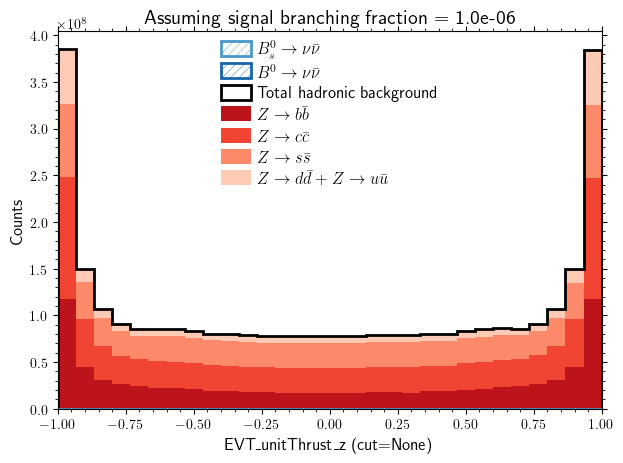

In [7]:
plot_variable(full_data, 'EVT_unitThrust_z', bins=30)

dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91=707169.083902679', 'n_p8_ee_Zcc_ecm91=288843.3389941839', 'n_p8_ee_Zss_ecm91=507690.41841892706', 'n_p8_ee_Zud_ecm91=97636.12455476035']
dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=38461.28832000001', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=168585.56320581815']


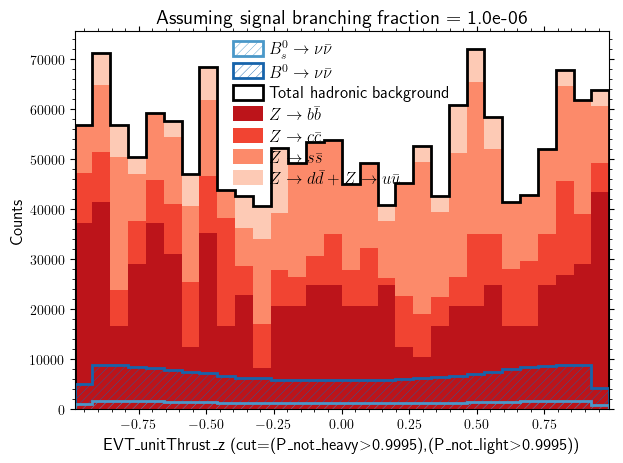

In [8]:
plot_variable(full_data, 'EVT_unitThrust_z', cut = "(P_not_heavy>0.9995)&(P_not_light>0.9995)",bins=30)

dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91'])
['n_p8_ee_Zbb_ecm91=7536933.657383815', 'n_p8_ee_Zcc_ecm91=8025512.173953399', 'n_p8_ee_Zss_ecm91=9899012.428048443', 'n_p8_ee_Zud_ecm91=1676086.8048567197']
dict_keys(['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu', 'p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Ztautau_ecm91'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=95570.16336000002', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=400345.20251345454']


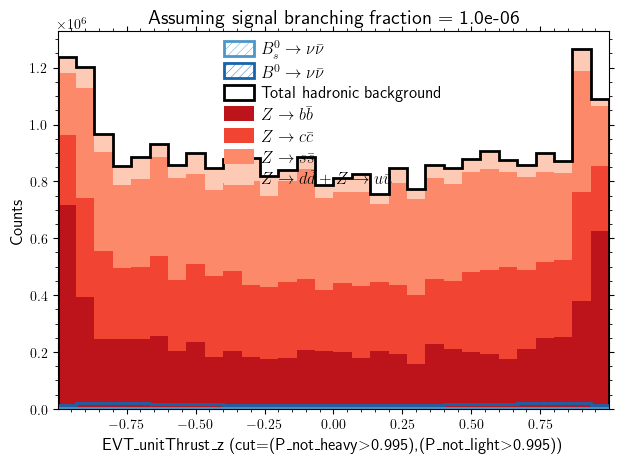

In [8]:
plot_variable(full_data, 'EVT_unitThrust_z', cut = "(P_not_heavy>0.995)&(P_not_light>0.995)",bins=30)

dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91=707169.083902679', 'n_p8_ee_Zcc_ecm91=288843.3389941839', 'n_p8_ee_Zss_ecm91=507690.41841892706', 'n_p8_ee_Zud_ecm91=97636.12455476035']
dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=38461.28832000001', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=168585.56320581815']


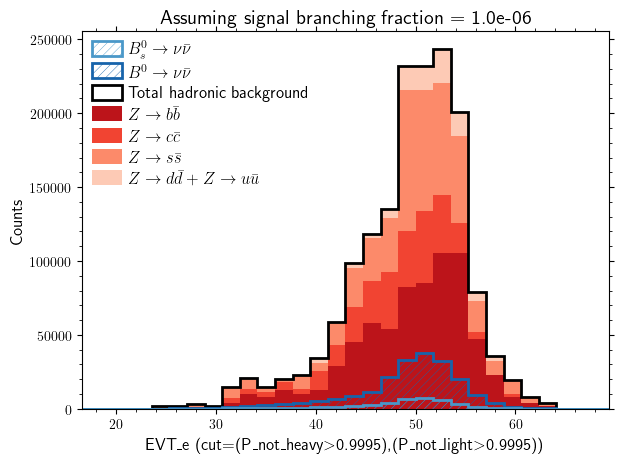

In [9]:
plot_variable(full_data, 'EVT_e', cut = "(P_not_heavy>0.9995)&(P_not_light>0.9995)",bins=30)

dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91=707169.083902679', 'n_p8_ee_Zcc_ecm91=288843.3389941839', 'n_p8_ee_Zss_ecm91=507690.41841892706', 'n_p8_ee_Zud_ecm91=97636.12455476035']
dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=38461.28832000001', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=168585.56320581815']


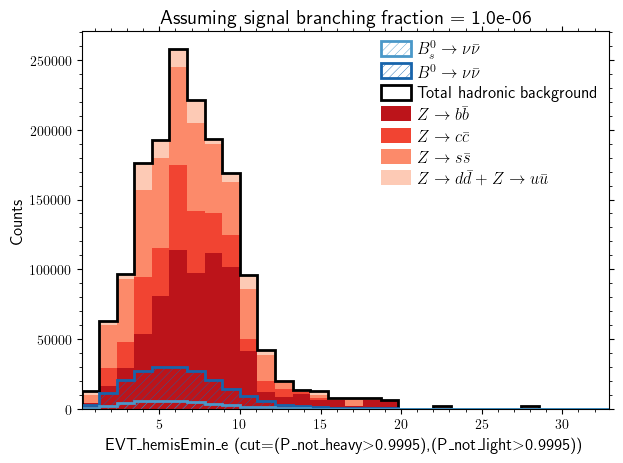

In [11]:
plot_variable(full_data, 'EVT_hemisEmin_e', cut = "(P_not_heavy>0.9995)&(P_not_light>0.9995)",bins=30)

dict_keys(['p8_ee_Zbb_ecm91', 'p8_ee_Zcc_ecm91', 'p8_ee_Zss_ecm91', 'p8_ee_Zud_ecm91', 'p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu', 'p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu'])
['n_p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu=38461.28832000001', 'n_p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu=168585.56320581815']


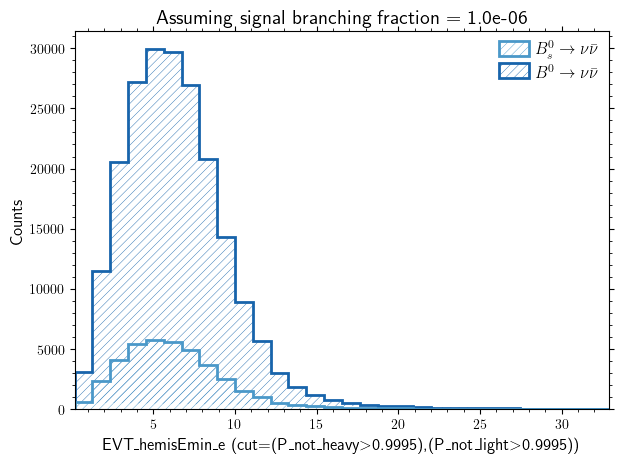

In [21]:
plot_variable(full_data, 'EVT_hemisEmin_e', cut = "(P_not_heavy>0.9995)&(P_not_light>0.9995)",bins=30, components=["combined_signal"])